# USV Step-Response Data Cleaning

Loads raw MATLAB-format data captured from an ArduPilot-based uncrewed surface vessel (USV),
cleans and aligns the multi-rate sensor streams, and exports a single CSV suitable for
ML model training.

**Inputs (RC output channels, PWM microseconds)**
- `RCOU_C1` — rudder command (1100–1900 µs, neutral = 1500)
- `RCOU_C3` — throttle command (1100–1900 µs, neutral = 1500)

**Outputs**
- `GPS_Spd` — forward speed (m/s)
- `IMU_GyrZ` — yaw rate (rad/s, positive = turn left / port)

**Sensor rates**
| Stream | Rate |
|--------|------|
| IMU    | ~137 Hz |
| RCOU   | ~9 Hz   |
| GPS    | ~5 Hz   |

In [1]:
import numpy as np
import pandas as pd
import scipy.io
import scipy.interpolate
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

MAT_FILE = 'step_resp_example.BIN.proc.mat'
OUT_CSV  = 'usv_step_response.csv'

# RC channel PWM range (ArduPilot standard)
PWM_MIN     = 1100   # full deflection
PWM_NEUTRAL = 1500   # center / zero command
PWM_MAX     = 1900   # full deflection
PWM_HALF    = (PWM_MAX - PWM_NEUTRAL)  # = 400

# Output sample rate for the cleaned dataset
OUT_HZ = 10.0
OUT_DT = 1.0 / OUT_HZ

# Gap threshold: intervals wider than this are treated as data gaps
GAP_THRESHOLD_S = 5.0

## 1. Load raw data

In [2]:
mat = scipy.io.loadmat(MAT_FILE, squeeze_me=True)
dd  = mat['dd']

imu_t  = dd['IMU_timestamp'].item().astype(np.float64)
gyr_z  = dd['IMU_GyrZ'].item().astype(np.float64)

rcou_t = dd['RCOU_timestamp'].item().astype(np.float64)
c1     = dd['RCOU_C1'].item().astype(np.float64)   # rudder
c3     = dd['RCOU_C3'].item().astype(np.float64)   # throttle

gps_t  = dd['GPS_timestamp'].item().astype(np.float64)
spd    = dd['GPS_Spd'].item().astype(np.float64)

# Common epoch: earliest timestamp across all streams
t0 = min(imu_t[0], rcou_t[0], gps_t[0])

imu_t_rel  = imu_t  - t0
rcou_t_rel = rcou_t - t0
gps_t_rel  = gps_t  - t0

print(f'Recording duration : {imu_t_rel[-1]:.1f} s')
print(f'IMU  samples       : {len(imu_t):6d}  (~{len(imu_t)/imu_t_rel[-1]:.0f} Hz)')
print(f'RCOU samples       : {len(rcou_t):6d}  (~{len(rcou_t)/rcou_t_rel[-1]:.0f} Hz)')
print(f'GPS  samples       : {len(gps_t):6d}  (~{len(gps_t)/gps_t_rel[-1]:.0f} Hz)')

Recording duration : 341.2 s
IMU  samples       :  46794  (~137 Hz)
RCOU samples       :   3119  (~9 Hz)
GPS  samples       :   1561  (~5 Hz)


## 2. Explore raw data

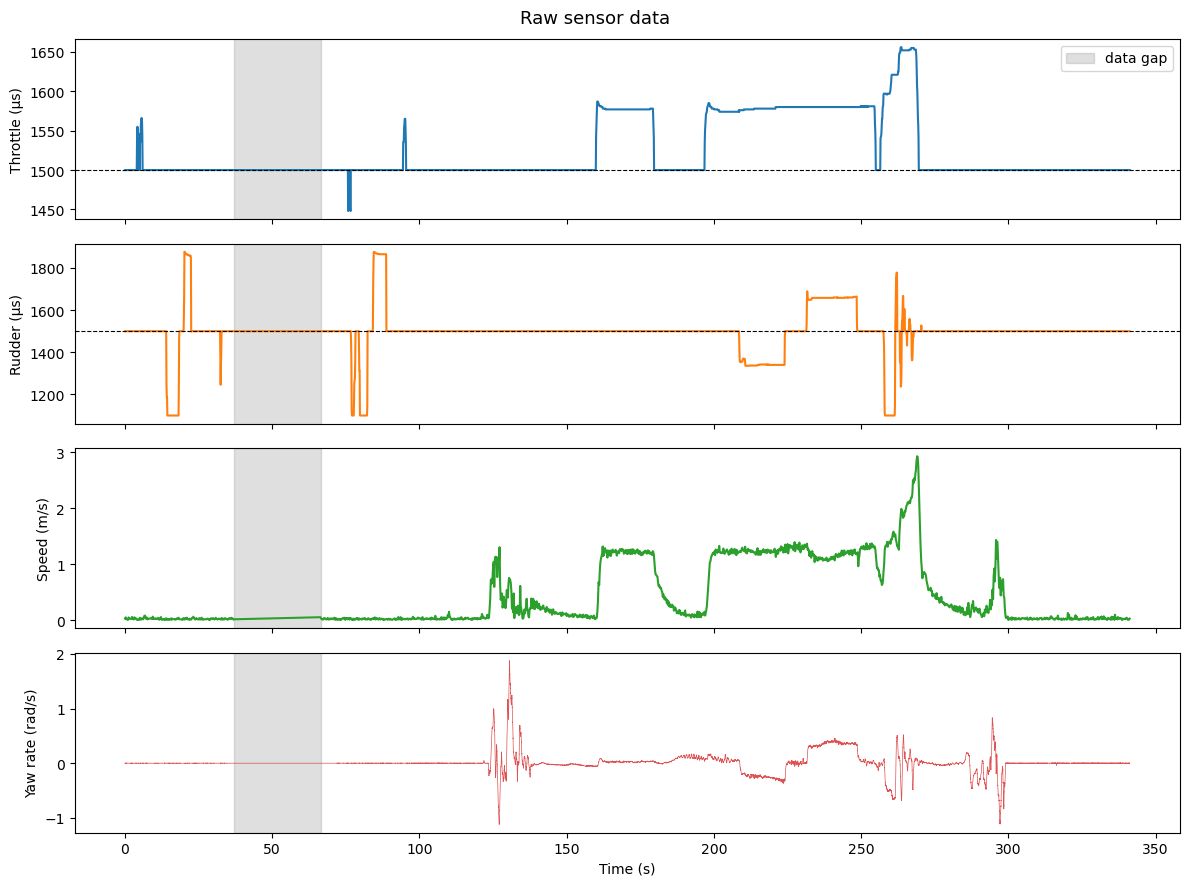

Data gap: 37.1 s – 66.5 s  (29.4 s)


In [3]:
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
fig.suptitle('Raw sensor data', fontsize=13)

axes[0].plot(rcou_t_rel, c3, color='C0')
axes[0].set_ylabel('Throttle (µs)')
axes[0].axhline(PWM_NEUTRAL, color='k', lw=0.8, ls='--')

axes[1].plot(rcou_t_rel, c1, color='C1')
axes[1].set_ylabel('Rudder (µs)')
axes[1].axhline(PWM_NEUTRAL, color='k', lw=0.8, ls='--')

axes[2].plot(gps_t_rel, spd, color='C2')
axes[2].set_ylabel('Speed (m/s)')

axes[3].plot(imu_t_rel, gyr_z, color='C3', lw=0.5, alpha=0.8)
axes[3].set_ylabel('Yaw rate (rad/s)')
axes[3].set_xlabel('Time (s)')

# Shade the data gap
rcou_diffs = np.diff(rcou_t_rel)
gap_idx = np.argmax(rcou_diffs)
gap_start = rcou_t_rel[gap_idx]
gap_end   = rcou_t_rel[gap_idx + 1]
for ax in axes:
    ax.axvspan(gap_start, gap_end, color='gray', alpha=0.25, label='data gap')

axes[0].legend(loc='upper right')
plt.tight_layout()
plt.savefig('raw_data.png', dpi=150)
plt.show()
print(f'Data gap: {gap_start:.1f} s – {gap_end:.1f} s  ({gap_end-gap_start:.1f} s)')

## 3. Clean data

### 3.1 Deduplicate IMU timestamps

ArduPilot logs multiple IMU samples sharing the same millisecond-precision timestamp.
We keep only unique timestamps (first occurrence) before interpolating.

In [4]:
_, unique_idx = np.unique(imu_t_rel, return_index=True)
imu_t_u = imu_t_rel[unique_idx]
gyr_z_u = gyr_z[unique_idx]
print(f'IMU: {len(imu_t_rel)} → {len(imu_t_u)} samples after deduplication')

IMU: 46794 → 15598 samples after deduplication


### 3.2 Normalize RC channels

Convert PWM microseconds to a dimensionless command in **[-1, 1]**:

$$u = \frac{\text{PWM} - 1500}{400}$$

where 400 µs is the half-range from neutral to maximum deflection.

In [5]:
rudder_raw   = (c1 - PWM_NEUTRAL) / PWM_HALF
throttle_raw = (c3 - PWM_NEUTRAL) / PWM_HALF

print(f'Rudder   normalized: [{rudder_raw.min():.3f}, {rudder_raw.max():.3f}]')
print(f'Throttle normalized: [{throttle_raw.min():.3f}, {throttle_raw.max():.3f}]')

Rudder   normalized: [-1.000, 0.943]
Throttle normalized: [-0.130, 0.390]


### 3.3 Identify continuous segments

Split the recording at any gap wider than `GAP_THRESHOLD_S` seconds.
Each segment is interpolated independently so gap boundaries are never bridged.

In [6]:
def find_segments(t, gap_threshold):
    """Return list of (start_time, end_time) for each continuous segment."""
    breaks = np.where(np.diff(t) > gap_threshold)[0]
    edges  = np.concatenate(([0], breaks + 1, [len(t)]))
    return [(t[edges[i]], t[edges[i+1] - 1]) for i in range(len(edges) - 1)]

# Use RCOU (slowest monotonic stream) to define segments
segments = find_segments(rcou_t_rel, GAP_THRESHOLD_S)
for i, (s, e) in enumerate(segments):
    print(f'  Segment {i}: {s:.1f} s – {e:.1f} s  ({e-s:.1f} s)')

  Segment 0: 0.1 s – 37.1 s  (37.0 s)
  Segment 1: 66.5 s – 341.2 s  (274.7 s)


### 3.4 Interpolate each segment to a common 10 Hz grid

In [7]:
def interp_segment(t_query, t_src, y_src, kind='linear'):
    """Interpolate y_src(t_src) at t_query, clamping to source bounds."""
    f = scipy.interpolate.interp1d(t_src, y_src, kind=kind,
                                   bounds_error=False, fill_value=np.nan)
    return f(t_query)

segment_dfs = []

for seg_idx, (seg_start, seg_end) in enumerate(segments):
    t_grid = np.arange(seg_start, seg_end + 1e-9, OUT_DT)

    # Mask each source stream to this segment
    def seg_mask(t_arr):
        return (t_arr >= seg_start - OUT_DT) & (t_arr <= seg_end + OUT_DT)

    imu_m  = seg_mask(imu_t_u)
    rcou_m = seg_mask(rcou_t_rel)
    gps_m  = seg_mask(gps_t_rel)

    throttle = interp_segment(t_grid, rcou_t_rel[rcou_m], throttle_raw[rcou_m])
    rudder   = interp_segment(t_grid, rcou_t_rel[rcou_m], rudder_raw[rcou_m])
    speed    = interp_segment(t_grid, gps_t_rel[gps_m],   spd[gps_m])
    yaw_rate = interp_segment(t_grid, imu_t_u[imu_m],     gyr_z_u[imu_m])

    df = pd.DataFrame({
        'time_s'       : t_grid,
        'throttle_norm': throttle,
        'rudder_norm'  : rudder,
        'speed_mps'    : speed,
        'yaw_rate_rps' : yaw_rate,
        'segment'      : seg_idx,
    })
    segment_dfs.append(df)
    print(f'Segment {seg_idx}: {len(df)} rows  NaN counts: '
          f'{df[["throttle_norm","rudder_norm","speed_mps","yaw_rate_rps"]].isna().sum().to_dict()}')

df_all = pd.concat(segment_dfs, ignore_index=True)

Segment 0: 371 rows  NaN counts: {'throttle_norm': 0, 'rudder_norm': 0, 'speed_mps': 1, 'yaw_rate_rps': 0}
Segment 1: 2748 rows  NaN counts: {'throttle_norm': 0, 'rudder_norm': 0, 'speed_mps': 0, 'yaw_rate_rps': 0}


## 4. Inspect cleaned data

In [8]:
print(df_all.describe())
print(f'\nTotal rows: {len(df_all)}')
print(f'Segments  : {df_all["segment"].nunique()}')

            time_s  throttle_norm  rudder_norm    speed_mps  yaw_rate_rps  \
count  3119.000000    3119.000000  3119.000000  3118.000000   3119.000000   
mean    181.794515       0.062439    -0.015640     0.465802      0.010851   
std      95.694479       0.100190     0.268438     0.579304      0.192870   
min       0.079740      -0.129993    -1.000000     0.002625     -1.112538   
25%     107.329698       0.000000     0.000000     0.024205     -0.000459   
50%     185.279698       0.000000     0.000000     0.103065      0.001160   
75%     263.229698       0.192500     0.000000     1.148458      0.023522   
max     341.179698       0.390000     0.942368     2.924838      1.873135   

           segment  
count  3119.000000  
mean      0.881052  
std       0.323780  
min       0.000000  
25%       1.000000  
50%       1.000000  
75%       1.000000  
max       1.000000  

Total rows: 3119
Segments  : 2


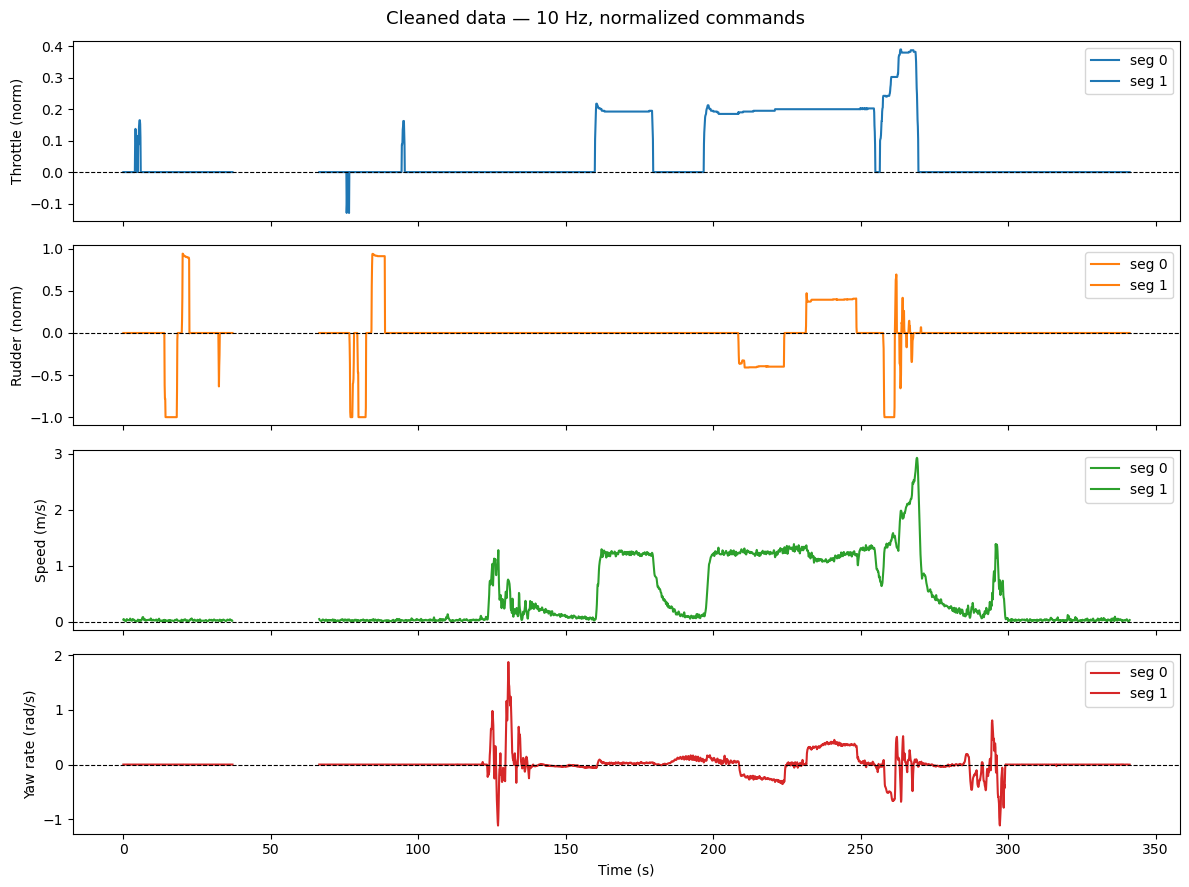

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
fig.suptitle(f'Cleaned data — {OUT_HZ:.0f} Hz, normalized commands', fontsize=13)

for seg_idx, grp in df_all.groupby('segment'):
    label = f'seg {seg_idx}'
    axes[0].plot(grp['time_s'], grp['throttle_norm'], color='C0', label=label)
    axes[1].plot(grp['time_s'], grp['rudder_norm'],   color='C1', label=label)
    axes[2].plot(grp['time_s'], grp['speed_mps'],     color='C2', label=label)
    axes[3].plot(grp['time_s'], grp['yaw_rate_rps'],  color='C3', label=label)

for ax, ylabel in zip(axes, ['Throttle (norm)', 'Rudder (norm)', 'Speed (m/s)', 'Yaw rate (rad/s)']):
    ax.set_ylabel(ylabel)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.legend(loc='upper right')

axes[3].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig('cleaned_data.png', dpi=150)
plt.show()

## 5. Save cleaned data

Output: `usv_step_response.csv`

| Column | Units | Description |
|--------|-------|-------------|
| `time_s` | s | Relative time from recording start |
| `throttle_norm` | — | Throttle command, normalized [-1, 1] |
| `rudder_norm` | — | Rudder command, normalized [-1, 1] |
| `speed_mps` | m/s | GPS forward speed |
| `yaw_rate_rps` | rad/s | IMU yaw rate (+ = port turn) |
| `segment` | — | Integer segment index (0 = first, 1 = second, …) |

In [10]:
df_all.to_csv(OUT_CSV, index=False, float_format='%.6f')
print(f'Saved {OUT_CSV}  ({len(df_all)} rows × {len(df_all.columns)} columns)')

# Quick verification
df_check = pd.read_csv(OUT_CSV)
print(df_check.head())
print(f'\nColumn dtypes:\n{df_check.dtypes}')

Saved usv_step_response.csv  (3119 rows × 6 columns)
    time_s  throttle_norm  rudder_norm  speed_mps  yaw_rate_rps  segment
0  0.07974            0.0          0.0   0.033616      0.001156        0
1  0.17974            0.0          0.0   0.044626      0.001531        0
2  0.27974            0.0          0.0   0.039851      0.001402        0
3  0.37974            0.0          0.0   0.024508      0.001036        0
4  0.47974            0.0          0.0   0.016813      0.000837        0

Column dtypes:
time_s           float64
throttle_norm    float64
rudder_norm      float64
speed_mps        float64
yaw_rate_rps     float64
segment            int64
dtype: object


## 6. Extract subset: 150 – 280 s

Isolate the window of interest for model training and save as a separate CSV.
Time is re-zeroed to the start of the subset.

Saved usv_step_response_150_280s.csv  (1300 rows, 130.0 s)
            time_s  throttle_norm  rudder_norm    speed_mps  yaw_rate_rps
count  1300.000000    1300.000000  1300.000000  1300.000000   1300.000000
mean     65.029698       0.147723    -0.022308     0.980849      0.022343
std      37.542198       0.106075     0.263922     0.548292      0.195050
min       0.079698       0.000000    -1.000000     0.016981     -0.678514
25%      32.554698       0.000000     0.000000     0.522776     -0.030795
50%      65.029698       0.192500     0.000000     1.198092      0.023940
75%      97.504698       0.200000     0.000000     1.248093      0.086261
max     129.979698       0.390000     0.694966     2.924838      0.519163


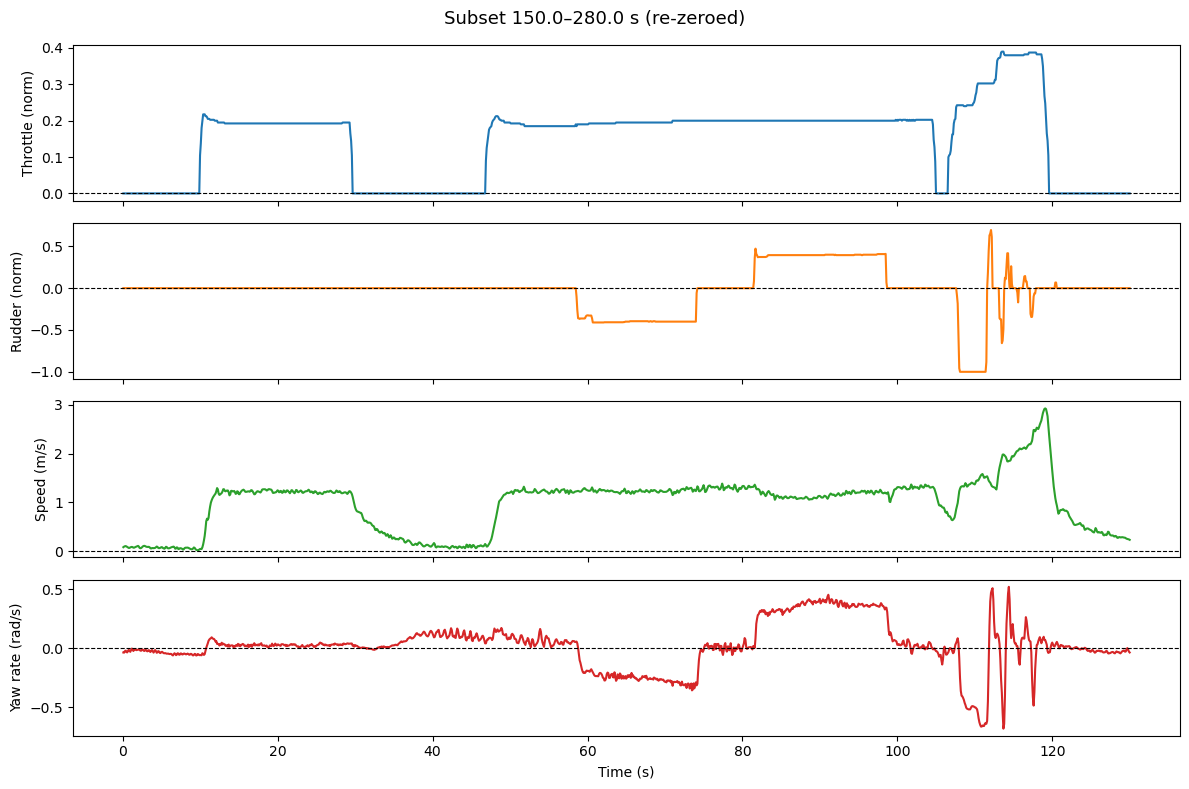

In [11]:
T_START = 150.0
T_END   = 280.0
SUBSET_CSV = 'usv_step_response_150_280s.csv'

df_sub = df_all[(df_all['time_s'] >= T_START) & (df_all['time_s'] <= T_END)].copy()
df_sub['time_s'] = df_sub['time_s'] - T_START   # re-zero time
df_sub = df_sub.drop(columns=['segment']).reset_index(drop=True)

df_sub.to_csv(SUBSET_CSV, index=False, float_format='%.6f')
print(f'Saved {SUBSET_CSV}  ({len(df_sub)} rows, {df_sub["time_s"].iloc[-1]:.1f} s)')
print(df_sub.describe())

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
fig.suptitle(f'Subset {T_START}–{T_END} s (re-zeroed)', fontsize=13)
axes[0].plot(df_sub['time_s'], df_sub['throttle_norm'], color='C0')
axes[0].set_ylabel('Throttle (norm)')
axes[1].plot(df_sub['time_s'], df_sub['rudder_norm'],   color='C1')
axes[1].set_ylabel('Rudder (norm)')
axes[2].plot(df_sub['time_s'], df_sub['speed_mps'],     color='C2')
axes[2].set_ylabel('Speed (m/s)')
axes[3].plot(df_sub['time_s'], df_sub['yaw_rate_rps'],  color='C3')
axes[3].set_ylabel('Yaw rate (rad/s)')
axes[3].set_xlabel('Time (s)')
for ax in axes:
    ax.axhline(0, color='k', lw=0.8, ls='--')
plt.tight_layout()
plt.savefig('subset_150_280s.png', dpi=150)
plt.show()